# Multi-Omics BRCA Cancer Subtype Prediction
A machine learning pipeline integrating RNA-seq, DNA methylation, and somatic mutation 
data from TCGA to classify breast cancer molecular subtypes.

## Section 1: Data Download
Querying and downloading TCGA-BRCA multi-omics data via the GDC REST API.

In [1]:
import requests
import pandas as pd
import json
import os
import numpy as np
import matplotlib.pyplot as plt
from functools import reduce

proxies = {
    "http": "http://10.99.0.130:3128",
    "https": "http://10.99.0.130:3128"
}

def query_gdc(endpoint, filters, fields, size=100):
    url = f"https://api.gdc.cancer.gov/{endpoint}"
    params = {
        "filters": json.dumps(filters),
        "fields": ",".join(fields),
        "format": "json",
        "size": size
    }
    response = requests.get(url, params=params, proxies=proxies)
    return response.json()

# Test GDC API connection
response = requests.get("https://api.gdc.cancer.gov/status", proxies=proxies)
print(response.json()['status'])
print(response.json()['data_release'])

OK
Data Release 45.0 - December 04, 2025


### 1.1 RNA-seq Data
Querying STAR-Counts gene expression files for all BRCA cases.

In [2]:
filters = {
    "op": "and",
    "content": [
        {"op": "=", "content": {"field": "cases.project.project_id", "value": "TCGA-BRCA"}},
        {"op": "=", "content": {"field": "data_type", "value": "Gene Expression Quantification"}},
        {"op": "=", "content": {"field": "analysis.workflow_type", "value": "STAR - Counts"}}
    ]
}

fields = ["file_id", "file_name", "cases.submitter_id", "cases.case_id"]

# 3. Run the query
rna_result = query_gdc("files", filters, fields, size=10)

# 4. Check output
print(f"Total files found: {rna_result['data']['pagination']['total']}")

# 5. Once confirmed, get ALL file IDs
result_all = query_gdc("files", filters, fields, size=1231)  # replace XXXX with total
rna_file_ids = [hit['file_id'] for hit in result_all['data']['hits']]
print(f"File IDs collected: {len(rna_file_ids)}")

Total files found: 1231
File IDs collected: 1231


### 1.2 Methylation Data
Querying Illumina 450k methylation array beta value files.

In [3]:
meth_filters = {
    "op": "and",
    "content": [
        {"op": "=", "content": {"field": "cases.project.project_id", "value": "TCGA-BRCA"}},
        {"op": "=", "content": {"field": "data_type", "value": "Methylation Beta Value"}},
        {"op": "=", "content": {"field": "platform", "value": "Illumina Human Methylation 450"}}
    ]
}
fields = ["file_id", "file_name", "cases.submitter_id", "cases.case_id"]

# 3. Run the query
methyl_result = query_gdc("files", meth_filters, fields, size=10)

# 4. Check output
print(f"Total files found: {methyl_result['data']['pagination']['total']}")

# 5. Once confirmed, get ALL file IDs
result_all = query_gdc("files", meth_filters, fields, size=895)  # replace XXXX with total
methyl_file_ids = [hit['file_id'] for hit in result_all['data']['hits']]
print(f"File IDs collected: {len(methyl_file_ids)}")

Total files found: 895
File IDs collected: 895


### 1.3 Mutation Data
Querying masked somatic mutation MAF files.

In [4]:
# Remove workflow filter and just peek at file names
mut_filters_peek = {
    "op": "and",
    "content": [
        {"op": "=", "content": {"field": "cases.project.project_id", "value": "TCGA-BRCA"}},
        {"op": "=", "content": {"field": "data_type", "value": "Masked Somatic Mutation"}},
        {"op": "=", "content": {"field": "data_format", "value": "MAF"}}
    ]
}

fields = ["file_id", "file_name", "analysis.workflow_type"]
peek = query_gdc("files", mut_filters_peek, fields, size=5)
for hit in peek['data']['hits']:
    print(hit['file_name'])
    print(hit.get('analysis', {}).get('workflow_type', 'N/A'))
    print()

01d89297-2636-4115-bfcf-993e9523401e.wxs.aliquot_ensemble_masked.maf.gz
Aliquot Ensemble Somatic Variant Merging and Masking

917569dc-8716-447b-b47f-654a639dfc74.wxs.aliquot_ensemble_masked.maf.gz
Aliquot Ensemble Somatic Variant Merging and Masking

fc2a9d28-f6bd-4b6b-bcc2-05c1eaf56dca.wxs.aliquot_ensemble_masked.maf.gz
Aliquot Ensemble Somatic Variant Merging and Masking

ac3dbb7f-2ce9-43b7-9f45-1c1521e6bbf5.wxs.aliquot_ensemble_masked.maf.gz
Aliquot Ensemble Somatic Variant Merging and Masking

d0f46c64-763a-4439-838c-bc95323a9290.wxs.aliquot_ensemble_masked.maf.gz
Aliquot Ensemble Somatic Variant Merging and Masking



### 1.4 Clinical Data
Querying patient clinical data and merging PAM50 subtypes from UCSC Xena.

In [5]:
# Fixed mutation filter
mut_filters = {
    "op": "and",
    "content": [
        {"op": "=", "content": {"field": "cases.project.project_id", "value": "TCGA-BRCA"}},
        {"op": "=", "content": {"field": "data_type", "value": "Masked Somatic Mutation"}},
        {"op": "=", "content": {"field": "data_format", "value": "MAF"}},
        {"op": "=", "content": {"field": "analysis.workflow_type", "value": "Aliquot Ensemble Somatic Variant Merging and Masking"}}
    ]
}

fields = ["file_id", "file_name", "cases.submitter_id", "cases.case_id"]
mut_result = query_gdc("files", mut_filters, fields, size=10)
print(f"Total files found: {mut_result['data']['pagination']['total']}")

result_all = query_gdc("files", mut_filters, fields, size=992)
mut_file_ids = [hit['file_id'] for hit in result_all['data']['hits']]
print(f"Mutation file IDs collected: {len(mut_file_ids)}")

Total files found: 992
Mutation file IDs collected: 992


In [6]:
clinical_fields = [
    "submitter_id",
    "demographic.gender",
    "diagnoses.age_at_diagnosis",
    "diagnoses.primary_diagnosis",
    "diagnoses.tumor_stage",
    "diagnoses.subtype"
]

clinical_filters = {
    "op": "=",
    "content": {
        "field": "project.project_id",        # which project?
        "value": "TCGA-BRCA"       # what value?
    }
}

clinical_all = query_gdc("cases", clinical_filters, clinical_fields, size=1098)
clinical_df = pd.json_normalize(clinical_all['data']['hits'])
print(clinical_df.shape)
print(clinical_df.columns.tolist())

(1098, 4)
['id', 'submitter_id', 'diagnoses', 'demographic.gender']


In [7]:
# Step 1 - extract first diagnosis per patient
clinical_df['diag_flat'] = clinical_df['diagnoses'].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else {})

# Step 2 - expand into columns
diagnoses_expanded = pd.json_normalize(clinical_df['diag_flat'])

print(diagnoses_expanded.columns.tolist())
print(diagnoses_expanded.head())

['age_at_diagnosis', 'primary_diagnosis']
   age_at_diagnosis                 primary_diagnosis
0           24053.0        Metaplastic carcinoma, NOS
1           25966.0  Infiltrating duct carcinoma, NOS
2           28233.0  Infiltrating duct carcinoma, NOS
3           20028.0  Infiltrating duct carcinoma, NOS
4           19028.0  Infiltrating duct carcinoma, NOS


In [8]:
import pandas as pd

# UCSC Xena BRCA phenotype file
xena_url = "https://tcga-xena-hub.s3.us-east-1.amazonaws.com/download/TCGA.BRCA.sampleMap%2FBRCA_clinicalMatrix"

# Download and read directly into pandas
xena_df = pd.read_csv(xena_url, sep="\t")

print(xena_df.shape)
print(xena_df.columns.tolist())

(1247, 194)
['sampleID', 'AJCC_Stage_nature2012', 'Age_at_Initial_Pathologic_Diagnosis_nature2012', 'CN_Clusters_nature2012', 'Converted_Stage_nature2012', 'Days_to_Date_of_Last_Contact_nature2012', 'Days_to_date_of_Death_nature2012', 'ER_Status_nature2012', 'Gender_nature2012', 'HER2_Final_Status_nature2012', 'Integrated_Clusters_no_exp__nature2012', 'Integrated_Clusters_unsup_exp__nature2012', 'Integrated_Clusters_with_PAM50__nature2012', 'Metastasis_Coded_nature2012', 'Metastasis_nature2012', 'Node_Coded_nature2012', 'Node_nature2012', 'OS_Time_nature2012', 'OS_event_nature2012', 'PAM50Call_RNAseq', 'PAM50_mRNA_nature2012', 'PR_Status_nature2012', 'RPPA_Clusters_nature2012', 'SigClust_Intrinsic_mRNA_nature2012', 'SigClust_Unsupervised_mRNA_nature2012', 'Survival_Data_Form_nature2012', 'Tumor_T1_Coded_nature2012', 'Tumor_nature2012', 'Vital_Status_nature2012', '_INTEGRATION', '_PANCAN_CNA_PANCAN_K8', '_PANCAN_Cluster_Cluster_PANCAN', '_PANCAN_DNAMethyl_BRCA', '_PANCAN_DNAMethyl_PANCA

In [9]:
# Step 1 - keep only useful columns from xena
xena_subset = xena_df[['sampleID', 'PAM50Call_RNAseq', 'ER_Status_nature2012', 
                         'PR_Status_nature2012', 'HER2_Final_Status_nature2012',
                         'pathologic_stage', 'age_at_initial_pathologic_diagnosis']]

print(xena_subset['PAM50Call_RNAseq'].value_counts())  # see subtype distribution

# Step 2 - merge with clinical_df
# Hint: sampleID in xena matches submitter_id in clinical_df
clinical_merged = pd.merge(clinical_df, xena_subset, 
                           left_on='submitter_id', 
                           right_on='sampleID',
                           how='left')

print(clinical_merged.shape)
print(clinical_merged['PAM50Call_RNAseq'].value_counts())

PAM50Call_RNAseq
LumA      434
LumB      194
Basal     142
Normal    119
Her2       67
Name: count, dtype: int64
(1098, 12)
Series([], Name: count, dtype: int64)


In [10]:
# Check what patient IDs look like in each dataframe
print("clinical_df submitter_id:")
print(clinical_df['submitter_id'].head())

print("\nxena_subset sampleID:")
print(xena_subset['sampleID'].head())

clinical_df submitter_id:
0    TCGA-E9-A5FL
1    TCGA-A2-A1G4
2    TCGA-BH-A0HF
3    TCGA-AR-A1AS
4    TCGA-D8-A13Y
Name: submitter_id, dtype: str

xena_subset sampleID:
0    TCGA-3C-AAAU-01
1    TCGA-3C-AALI-01
2    TCGA-3C-AALJ-01
3    TCGA-3C-AALK-01
4    TCGA-4H-AAAK-01
Name: sampleID, dtype: str


In [11]:
# Trim xena sampleID to match patient ID format
xena_subset['patient_id'] = xena_subset['sampleID'].apply(lambda x:x[:12])

# Now merge on the trimmed ID
clinical_merged = pd.merge(clinical_df, xena_subset,
                           left_on='submitter_id',
                           right_on='patient_id',
                           how='left')

print(clinical_merged['PAM50Call_RNAseq'].value_counts())

PAM50Call_RNAseq
LumA      434
LumB      194
Basal     141
Normal    119
Her2       67
Name: count, dtype: int64


In [12]:
# Keep only useful columns
clinical_final = clinical_merged[['submitter_id', 'PAM50Call_RNAseq', 
                                   'ER_Status_nature2012', 'PR_Status_nature2012',
                                   'HER2_Final_Status_nature2012', 'pathologic_stage',
                                   'age_at_initial_pathologic_diagnosis',
                                   'demographic.gender']]

# Rename PAM50 column to something cleaner
clinical_final = clinical_final.rename(columns={'PAM50Call_RNAseq': 'PAM50'})

# Save to processed folder
clinical_final.to_csv('/scratch/arumuganainar.d/projects/Multiomics/data/processed/clinical.csv', index=False)


print(f"Saved {clinical_final.shape[0]} patients")
print(clinical_final.head())

Saved 1244 patients
   submitter_id PAM50 ER_Status_nature2012 PR_Status_nature2012  \
0  TCGA-E9-A5FL   NaN                  NaN                  NaN   
1  TCGA-A2-A1G4  LumB             Positive             Positive   
2  TCGA-BH-A0HF  LumA             Positive             Positive   
3  TCGA-AR-A1AS  LumA             Positive             Positive   
4  TCGA-D8-A13Y  LumB             Positive             Positive   

  HER2_Final_Status_nature2012 pathologic_stage  \
0                          NaN        Stage IIB   
1                     Negative       Stage IIIA   
2                     Negative         Stage IA   
3                     Negative        Stage IIB   
4                     Negative         Stage IA   

   age_at_initial_pathologic_diagnosis demographic.gender  
0                                 65.0             female  
1                                 71.0             female  
2                                 77.0             female  
3                             

## Section 2: Exploratory Data Analysis
Exploring each omics layer to understand distributions and data quality.

### 2.1 RNA-seq EDA

In [13]:
import os
import pandas as pd
rnaseq_dir = "/scratch/arumuganainar.d/projects/Multiomics/data/raw/rnaseq/"

# Step 1 - peek at one file first before loading all 1231
sample_folder = os.listdir(rnaseq_dir)[0]
sample_file = [f for f in os.listdir(os.path.join(rnaseq_dir, sample_folder)) if f.endswith('.tsv')][0]
sample_path = os.path.join(rnaseq_dir, sample_folder, sample_file)

df_test = pd.read_csv(sample_path, sep="\t", comment="#", skiprows=1)
print(df_test.columns.tolist())
print(df_test.head(10))

['gene_id', 'gene_name', 'gene_type', 'unstranded', 'stranded_first', 'stranded_second', 'tpm_unstranded', 'fpkm_unstranded', 'fpkm_uq_unstranded']
              gene_id gene_name       gene_type  unstranded  stranded_first  \
0          N_unmapped       NaN             NaN     1884156         1884156   
1      N_multimapping       NaN             NaN     5772894         5772894   
2         N_noFeature       NaN             NaN     3331800        41101584   
3         N_ambiguous       NaN             NaN     6974507         1651293   
4  ENSG00000000003.15    TSPAN6  protein_coding        4370            2153   
5   ENSG00000000005.6      TNMD  protein_coding           7               2   
6  ENSG00000000419.13      DPM1  protein_coding        2625            1314   
7  ENSG00000000457.14     SCYL3  protein_coding        3005            2389   
8  ENSG00000000460.17  C1orf112  protein_coding        1578            1728   
9  ENSG00000000938.13       FGR  protein_coding         599   

In [14]:
from functools import reduce

dfs = []
for folder in os.listdir(rnaseq_dir):
    folder_path = os.path.join(rnaseq_dir, folder)
    if not os.path.isdir(folder_path):
        continue
    tsv_files = [f for f in os.listdir(folder_path) if f.endswith('.tsv')]
    if not tsv_files:
        continue
    file_path = os.path.join(folder_path, tsv_files[0])
    
    df = pd.read_csv(file_path, sep="\t", comment="#", skiprows=1)
    df = df[df['gene_id'].str.startswith('ENSG')]  # remove QC rows
    df = df[['gene_id','unstranded']]  # keep only gene_id and counts
    df = df.rename(columns={'unstranded': folder})  # rename count col to sample/folder name
    dfs.append(df)

print(f"Loaded {len(dfs)} samples")

# Merge all into one matrix
rnaseq_matrix = reduce(lambda left, right: pd.merge(left, right, on='gene_id'), dfs)
print(rnaseq_matrix.shape)

Loaded 1231 samples
(60660, 1232)


In [15]:
# Set gene_id as the index — like rownames in R
rnaseq_matrix = rnaseq_matrix.set_index('gene_id')

# Basic stats
print("Shape:", rnaseq_matrix.shape)
print("\nMissing values:", rnaseq_matrix.isnull().sum().sum())
print("\nFirst few genes:")
print(rnaseq_matrix.iloc[:5, :5])  # first 5 genes, first 5 samples

# Distribution of counts for one sample
print("\nBasic stats for first sample:")
print(rnaseq_matrix.iloc[:, 0].describe())

Shape: (60660, 1231)

Missing values: 0

First few genes:
                    0019c951-16c5-48d0-85c8-58d96b12d330  \
gene_id                                                    
ENSG00000000003.15                                  4370   
ENSG00000000005.6                                      7   
ENSG00000000419.13                                  2625   
ENSG00000000457.14                                  3005   
ENSG00000000460.17                                  1578   

                    0022cd20-f64f-4773-b9ff-a3de0b71b259  \
gene_id                                                    
ENSG00000000003.15                                  2443   
ENSG00000000005.6                                    144   
ENSG00000000419.13                                  2322   
ENSG00000000457.14                                  1466   
ENSG00000000460.17                                   409   

                    00469928-b243-4cae-acd7-134508e99ceb  \
gene_id                                 

In [16]:
# Save RNA-seq matrix
rnaseq_matrix.to_parquet("/scratch/arumuganainar.d/projects/Multiomics/data/processed/rnaseq_matrix.parquet")

print("Saved!")

Saved!


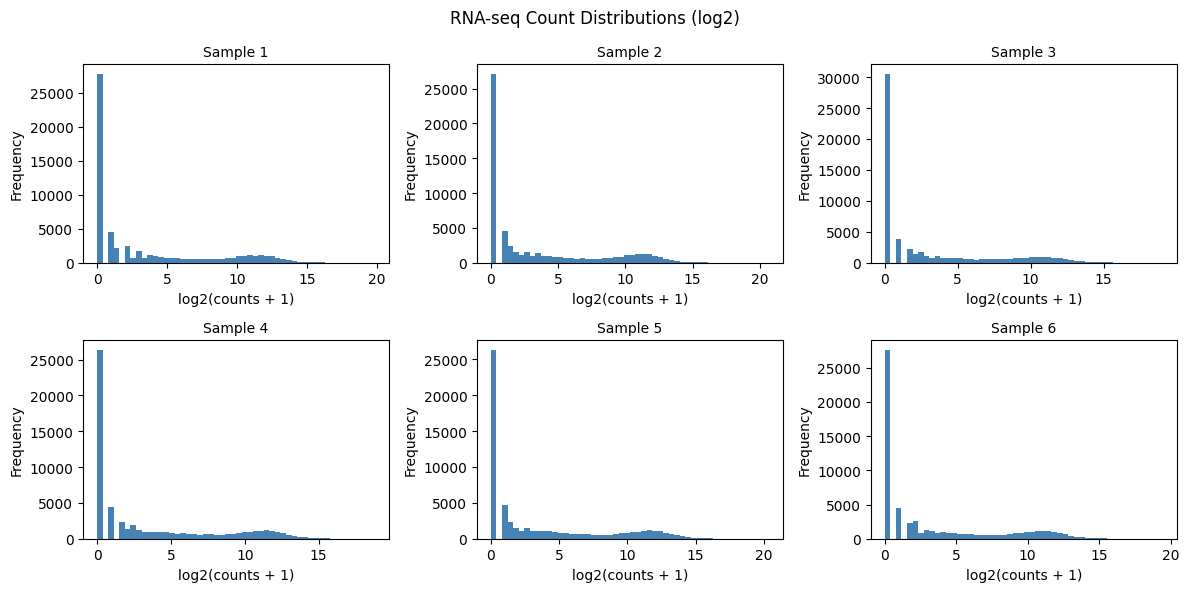

Plot saved!


In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Log2 transform the entire matrix
rnaseq_log = np.log2(rnaseq_matrix + 1)

# Plot distribution for first 6 samples
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()

for i in range(6):
    axes[i].hist(rnaseq_log.iloc[:, i], bins=50, color='steelblue', edgecolor='none')
    axes[i].set_title(f"Sample {i+1}", fontsize=10)
    axes[i].set_xlabel("log2(counts + 1)")
    axes[i].set_ylabel("Frequency")

plt.suptitle("RNA-seq Count Distributions (log2)")
plt.tight_layout()
plt.savefig('/scratch/arumuganainar.d/projects/Multiomics/data/processed/rnaseq_distribution.png', dpi=100)
plt.show()
print("Plot saved!")

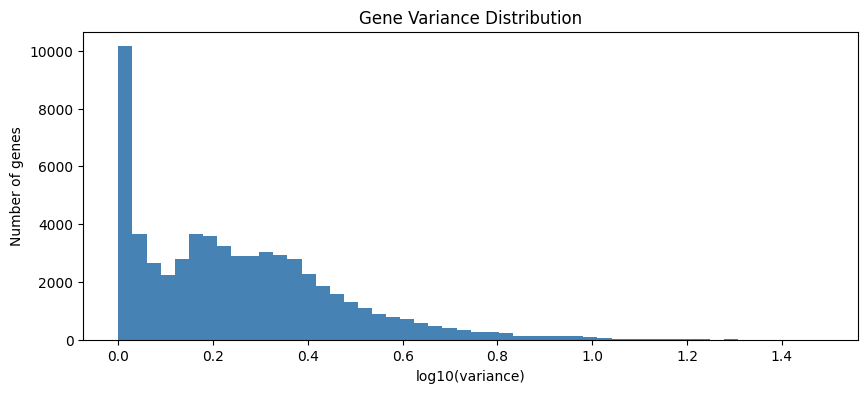

Genes with zero variance: 2612
Top 5 most variable genes:
gene_id
ENSG00000166509.12    29.686397
ENSG00000110484.7     25.517005
ENSG00000153002.12    24.472357
ENSG00000134184.13    23.641126
ENSG00000160182.3     21.087041
dtype: float64


In [18]:
gene_var = rnaseq_log.var(axis=1)

plt.figure(figsize=(10, 4))
plt.hist(np.log10(gene_var + 1), bins=50, color='steelblue', edgecolor='none')
plt.xlabel("log10(variance)")
plt.ylabel("Number of genes")
plt.title("Gene Variance Distribution")
plt.savefig('/scratch/arumuganainar.d/projects/Multiomics/data/processed/rnaseq_variance.png', dpi=100)
plt.show()

print(f"Genes with zero variance: {(gene_var == 0).sum()}")
print(f"Top 5 most variable genes:\n{gene_var.sort_values(ascending=False).head()}")

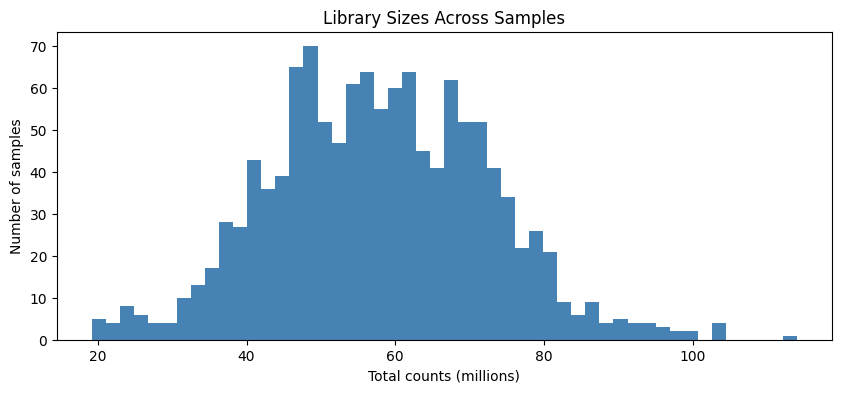

Min library size: 19,225,117
Max library size: 114,015,705
Mean library size: 57,967,462


In [19]:
library_sizes = rnaseq_matrix.sum(axis=0)

plt.figure(figsize=(10, 4))
plt.hist(library_sizes / 1e6, bins=50, color='steelblue', edgecolor='none')
plt.xlabel("Total counts (millions)")
plt.ylabel("Number of samples")
plt.title("Library Sizes Across Samples")
plt.savefig('/scratch/arumuganainar.d/projects/Multiomics/data/processed/rnaseq_library_sizes.png', dpi=100)
plt.show()

print(f"Min library size: {library_sizes.min():,.0f}")
print(f"Max library size: {library_sizes.max():,.0f}")
print(f"Mean library size: {library_sizes.mean():,.0f}")

### 2.2 Methylation EDA

In [20]:
meth_dir = "/scratch/arumuganainar.d/projects/Multiomics/data/raw/methylation/"

sample_folder = os.listdir(meth_dir)[0]
sample_folder_path = os.path.join(meth_dir, sample_folder)
sample_file = [f for f in os.listdir(sample_folder_path) if not f.endswith('.parcel')][0]
sample_path = os.path.join(sample_folder_path, sample_file)

print("File name:", sample_file)
df_test = pd.read_csv(sample_path, sep="\t", header=None, names=['probe_id', 'beta_value'], nrows=10)
print(df_test.head(10))
print(df_test.columns.tolist())

File name: 76de947f-b1a3-464d-a097-c8298f5ac8e5.methylation_array.sesame.level3betas.txt
     probe_id  beta_value
0  cg00000029    0.103123
1  cg00000108    0.972492
2  cg00000109    0.942532
3  cg00000165    0.857995
4  cg00000236    0.790061
5  cg00000289    0.842689
6  cg00000292    0.304769
7  cg00000321    0.229645
8  cg00000363    0.125852
9  cg00000622    0.011558
['probe_id', 'beta_value']


In [21]:
dfs_meth = []

for folder in os.listdir(meth_dir):
    folder_path = os.path.join(meth_dir, folder)
    if not os.path.isdir(folder_path):
        continue
    files = [f for f in os.listdir(folder_path) if not f.endswith('.parcel')]
    if not files:
        continue
    file_path = os.path.join(folder_path, files[0])
    
    df = pd.read_csv(file_path, sep="\t", header=None, names=['probe_id', 'beta_value'])
    df = df.rename(columns={'beta_value': folder})
    dfs_meth.append(df)

print(f"Loaded {len(dfs_meth)} samples")

meth_matrix = reduce(lambda left, right: pd.merge(left, right, on='probe_id'), dfs_meth)
meth_matrix = meth_matrix.set_index('probe_id')
print(meth_matrix.shape)

Loaded 895 samples
(0, 895)


In [22]:
# Check probe IDs from first two files
folders = [f for f in os.listdir(meth_dir) if os.path.isdir(os.path.join(meth_dir, f))]

for i in range(2):
    folder_path = os.path.join(meth_dir, folders[i])
    files = [f for f in os.listdir(folder_path) if not f.endswith('.parcel')]
    file_path = os.path.join(folder_path, files[0])
    df = pd.read_csv(file_path, sep="\t", header=None, names=['probe_id', 'beta_value'])
    print(f"Sample {i+1}:")
    print(df['probe_id'].head())
    print(f"Total probes: {len(df)}")
    print()

Sample 1:
0    cg00000029
1    cg00000108
2    cg00000109
3    cg00000165
4    cg00000236
Name: probe_id, dtype: str
Total probes: 486427

Sample 2:
0    cg00000029
1    cg00000108
2    cg00000109
3    cg00000165
4    cg00000236
Name: probe_id, dtype: str
Total probes: 486427



In [23]:
dfs_meth = []

for folder in os.listdir(meth_dir):
    folder_path = os.path.join(meth_dir, folder)
    if not os.path.isdir(folder_path):
        continue
    files = [f for f in os.listdir(folder_path) if not f.endswith('.parcel')]
    if not files:
        continue
    file_path = os.path.join(folder_path, files[0])
    
    df = pd.read_csv(file_path, sep="\t", header=None, names=['probe_id', 'beta_value'])
    df = df.set_index('probe_id')
    df = df.rename(columns={'beta_value': folder})
    dfs_meth.append(df)

print(f"Loaded {len(dfs_meth)} samples")

# Concat all along columns
meth_matrix = pd.concat(dfs_meth, axis=1)
print(meth_matrix.shape)

Loaded 895 samples
(486429, 895)


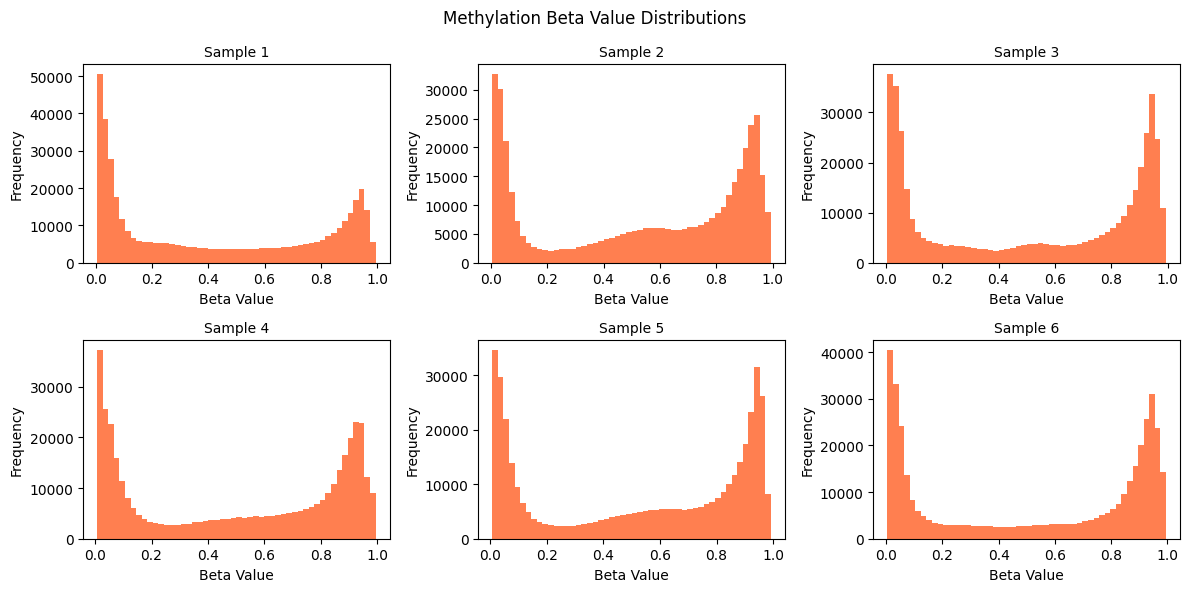

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()
for i in range(6):
    axes[i].hist(meth_matrix.iloc[:, i].dropna(), bins=50, color='coral', edgecolor='none')
    axes[i].set_title(f"Sample {i+1}", fontsize=10)
    axes[i].set_xlabel("Beta Value")
    axes[i].set_ylabel("Frequency")
plt.suptitle("Methylation Beta Value Distributions")
plt.tight_layout()
plt.savefig('/scratch/arumuganainar.d/projects/Multiomics/data/processed/meth_distribution.png', dpi=100)
plt.show()

### 3.2 Methylation Preprocessing

In [25]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

meth_matrix = meth_matrix[meth_matrix.index.str.startswith('cg')]
meth_matrix = meth_matrix.apply(pd.to_numeric, errors='coerce')

probe_var = meth_matrix.var(axis=1)
top_probes = probe_var.nlargest(5000).index
meth_filtered = meth_matrix.loc[top_probes]

imputer = SimpleImputer(strategy='mean')
meth_imputed = imputer.fit_transform(meth_filtered.T)
meth_imputed = pd.DataFrame(meth_imputed.T,
                             index=meth_filtered.index,
                             columns=meth_filtered.columns)

scaler = StandardScaler()
meth_scaled = scaler.fit_transform(meth_imputed.T)
meth_scaled = pd.DataFrame(meth_scaled.T,
                            index=meth_imputed.index,
                            columns=meth_imputed.columns)

print(meth_scaled.shape)
meth_scaled.to_parquet("/scratch/arumuganainar.d/projects/Multiomics/data/processed/meth_preprocessed.parquet")
print("Saved!")

(5000, 895)
Saved!


### 2.3 Mutation EDA

In [26]:
mut_dir = "/scratch/arumuganainar.d/projects/Multiomics/data/raw/mutation/"
mutation_records = []

for folder in os.listdir(mut_dir):
    folder_path = os.path.join(mut_dir, folder)
    if not os.path.isdir(folder_path):
        continue
    files = [f for f in os.listdir(folder_path) if f.endswith('.gz')]
    if not files:
        continue
    file_path = os.path.join(folder_path, files[0])
    
    df = pd.read_csv(file_path, sep="\t", comment="#",
                     usecols=['Hugo_Symbol', 'Tumor_Sample_Barcode'])
    if len(df) == 0:
        continue
    
    patient_id = df['Tumor_Sample_Barcode'].iloc[0][:12]
    genes = df['Hugo_Symbol'].unique().tolist()
    for gene in genes:
        mutation_records.append({'patient_id': patient_id, 'gene': gene, 'mutated': 1})

print(f"Total mutation records: {len(mutation_records)}")
mut_df = pd.DataFrame(mutation_records)

Total mutation records: 84417


In [27]:
mut_matrix = mut_df.pivot_table(index='patient_id', columns='gene', 
                                 values='mutated', aggfunc='max').fillna(0)
print(mut_matrix.shape)
mut_matrix.to_parquet("/scratch/arumuganainar.d/projects/Multiomics/data/processed/mut_matrix.parquet")
print("Saved!")

(968, 16662)
Saved!


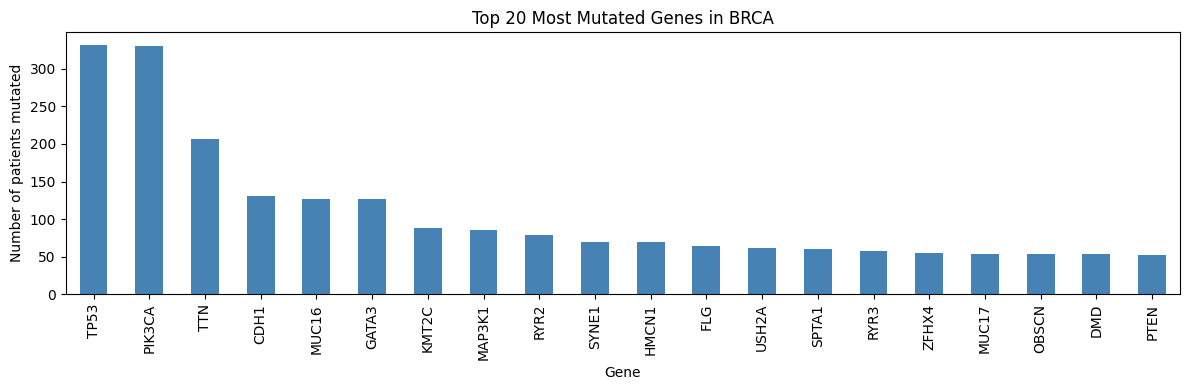

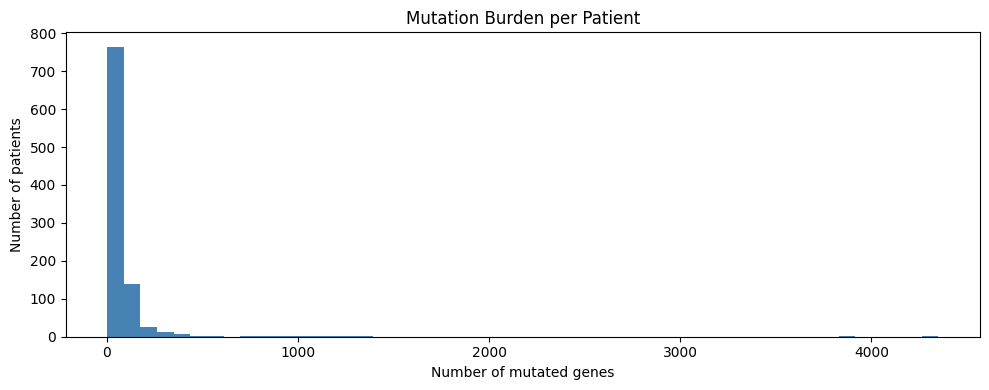

Mean mutations per patient: 86.3
Max mutations per patient: 4351


In [28]:
gene_mutation_freq = mut_matrix.sum(axis=0).sort_values(ascending=False)
plt.figure(figsize=(12, 4))
gene_mutation_freq.head(20).plot(kind='bar', color='steelblue')
plt.xlabel("Gene")
plt.ylabel("Number of patients mutated")
plt.title("Top 20 Most Mutated Genes in BRCA")
plt.tight_layout()
plt.savefig('/scratch/arumuganainar.d/projects/Multiomics/data/processed/mutation_top_genes.png', dpi=100)
plt.show()

mutation_burden = mut_matrix.sum(axis=1)
plt.figure(figsize=(10, 4))
plt.hist(mutation_burden, bins=50, color='steelblue', edgecolor='none')
plt.xlabel("Number of mutated genes")
plt.ylabel("Number of patients")
plt.title("Mutation Burden per Patient")
plt.tight_layout()
plt.savefig('/scratch/arumuganainar.d/projects/Multiomics/data/processed/mutation_burden.png', dpi=100)
plt.show()

print(f"Mean mutations per patient: {mutation_burden.mean():.1f}")
print(f"Max mutations per patient: {mutation_burden.max():.0f}")

### 3.3 Mutation Preprocessing
Remove hypermutated outlier, filter rarely mutated genes, keep clinically relevant mutations only.

In [29]:
# Step 1 - remove hypermutated outlier
mutation_burden = mut_matrix.sum(axis=1)
mut_matrix_clean = mut_matrix[mutation_burden < 500]  # remove samples with > 500 mutations
print(f"Samples after removing outlier: {mut_matrix_clean.shape[0]}")

# Step 2 - filter genes mutated in at least 5% of patients
min_patients = int(0.05 * mut_matrix_clean.shape[0])
gene_counts = mut_matrix_clean.sum(axis=0)
mut_matrix_filtered = mut_matrix_clean.loc[:, gene_counts >= min_patients]
print(f"Before filtering: {mut_matrix_clean.shape}")
print(f"After filtering: {mut_matrix_filtered.shape}")

# See which 18 genes passed the filter
print("Recurrently mutated genes:")
print(mut_matrix_filtered.columns.tolist())

# Save
mut_matrix_filtered.to_parquet("/scratch/arumuganainar.d/projects/Multiomics/data/processed/mut_preprocessed.parquet")
print("Saved!")

Samples after removing outlier: 952
Before filtering: (952, 16662)
After filtering: (952, 18)
Recurrently mutated genes:
['CDH1', 'DMD', 'FLG', 'GATA3', 'HMCN1', 'KMT2C', 'MAP3K1', 'MUC16', 'MUC17', 'PIK3CA', 'RYR2', 'RYR3', 'SPTA1', 'SYNE1', 'TP53', 'TTN', 'USH2A', 'ZFHX4']
Saved!


## Section 3: Preprocessing
Filtering, normalizing and aligning all omics matrices to a common patient set.

### 3.1 RNA-seq Preprocessing

In [30]:
# Load all preprocessed matrices from disk
rnaseq_scaled = pd.read_parquet("/scratch/arumuganainar.d/projects/Multiomics/data/processed/rnaseq_preprocessed.parquet")
meth_scaled = pd.read_parquet("/scratch/arumuganainar.d/projects/Multiomics/data/processed/meth_preprocessed.parquet")
mut_matrix_filtered = pd.read_parquet("/scratch/arumuganainar.d/projects/Multiomics/data/processed/mut_preprocessed.parquet")
clinical_final = pd.read_csv("/scratch/arumuganainar.d/projects/Multiomics/data/processed/clinical.csv")

print("RNA-seq:", rnaseq_scaled.shape)
print("Methylation:", meth_scaled.shape)
print("Mutation:", mut_matrix_filtered.shape)
print("Clinical:", clinical_final.shape)


print("RNA-seq columns (first 3):")
print(rnaseq_scaled.columns[:3].tolist())

print("\nMethylation columns (first 3):")
print(meth_scaled.columns[:3].tolist())

print("\nMutation index (first 3):")
print(mut_matrix_filtered.index[:3].tolist())

print("\nClinical submitter_id (first 3):")
print(clinical_final['submitter_id'][:3].tolist())

RNA-seq: (5000, 1231)
Methylation: (5000, 895)
Mutation: (952, 18)
Clinical: (1244, 8)
RNA-seq columns (first 3):
['0019c951-16c5-48d0-85c8-58d96b12d330', '0022cd20-f64f-4773-b9ff-a3de0b71b259', '00469928-b243-4cae-acd7-134508e99ceb']

Methylation columns (first 3):
['0030cccf-0ac2-4f88-9d06-15e3f1569bbb', '00640589-db82-485f-aec9-8ffde073fb42', '0079b380-6f22-46d4-b86f-e63772ee0b5a']

Mutation index (first 3):
['TCGA-3C-AAAU', 'TCGA-3C-AALJ', 'TCGA-3C-AALK']

Clinical submitter_id (first 3):
['TCGA-E9-A5FL', 'TCGA-A2-A1G4', 'TCGA-BH-A0HF']


In [31]:
rnaseq_filters = {
    "op": "and",
    "content": [
        {"op": "=", "content": {"field": "cases.project.project_id", "value": "TCGA-BRCA"}},
        {"op": "=", "content": {"field": "data_type", "value": "Gene Expression Quantification"}},
        {"op": "=", "content": {"field": "analysis.workflow_type", "value": "STAR - Counts"}}
    ]
}

meth_filters = {
    "op": "and",
    "content": [
        {"op": "=", "content": {"field": "cases.project.project_id", "value": "TCGA-BRCA"}},
        {"op": "=", "content": {"field": "data_type", "value": "Methylation Beta Value"}},
        {"op": "=", "content": {"field": "platform", "value": "Illumina Human Methylation 450"}}
    ]
}

fields = ["file_id", "cases.submitter_id"]

result_rna = query_gdc("files", rnaseq_filters, fields, size=1231)
rna_id_map = {}
for hit in result_rna['data']['hits']:
    file_id = hit['file_id']
    patient_id = hit['cases'][0]['submitter_id']
    rna_id_map[file_id] = patient_id

result_meth = query_gdc("files", meth_filters, fields, size=895)
meth_id_map = {}
for hit in result_meth['data']['hits']:
    file_id = hit['file_id']
    patient_id = hit['cases'][0]['submitter_id']
    meth_id_map[file_id] = patient_id

print(f"RNA-seq ID map size: {len(rna_id_map)}")
print(f"Methylation ID map size: {len(meth_id_map)}")

RNA-seq ID map size: 1231
Methylation ID map size: 895


In [32]:
import json

with open("/scratch/arumuganainar.d/projects/Multiomics/data/processed/rna_id_map.json", "w") as f:
    json.dump(rna_id_map, f)

with open("/scratch/arumuganainar.d/projects/Multiomics/data/processed/meth_id_map.json", "w") as f:
    json.dump(meth_id_map, f)

print("Mappings saved!")

Mappings saved!


In [33]:
# Rename RNA-seq columns from UUID to patient ID
rnaseq_scaled.columns = [rna_id_map.get(col, col) for col in rnaseq_scaled.columns]

# Rename methylation columns from UUID to patient ID
meth_scaled.columns = [meth_id_map.get(col, col) for col in meth_scaled.columns]

# Verify
print("RNA-seq columns (first 3):")
print(rnaseq_scaled.columns[:3].tolist())

print("\nMethylation columns (first 3):")
print(meth_scaled.columns[:3].tolist())

print("\nMutation index (first 3):")
print(mut_matrix_filtered.index[:3].tolist())

print("\nClinical submitter_id (first 3):")
print(clinical_final['submitter_id'][:3].tolist())

RNA-seq columns (first 3):
['TCGA-D8-A1XO', 'TCGA-AN-A0FN', 'TCGA-AC-A62X']

Methylation columns (first 3):
['TCGA-E2-A1LG', 'TCGA-AR-A5QN', 'TCGA-AC-A3TN']

Mutation index (first 3):
['TCGA-3C-AAAU', 'TCGA-3C-AALJ', 'TCGA-3C-AALK']

Clinical submitter_id (first 3):
['TCGA-E9-A5FL', 'TCGA-A2-A1G4', 'TCGA-BH-A0HF']


In [34]:
# Get patient IDs from each dataset
rna_patients = set(rnaseq_scaled.columns)
meth_patients = set(meth_scaled.columns)
mut_patients = set(mut_matrix_filtered.index)
clinical_patients = set(clinical_final['submitter_id'])

# Find common patients across all four
common_patients = rna_patients & meth_patients & mut_patients & clinical_patients
common_patients = sorted(common_patients)  # sort for consistency
print(f"RNA-seq patients: {len(rna_patients)}")
print(f"Methylation patients: {len(meth_patients)}")
print(f"Mutation patients: {len(mut_patients)}")
print(f"Clinical patients: {len(clinical_patients)}")
print(f"\nCommon patients: {len(common_patients)}")

RNA-seq patients: 1095
Methylation patients: 791
Mutation patients: 952
Clinical patients: 1098

Common patients: 667


In [35]:
# Filter each matrix to common patients
rnaseq_aligned = rnaseq_scaled[common_patients]
meth_aligned = meth_scaled[common_patients]
mut_aligned = mut_matrix_filtered.loc[common_patients]
clinical_aligned = clinical_final[clinical_final['submitter_id'].isin(common_patients)].set_index('submitter_id').loc[common_patients]
print("RNA-seq aligned:", rnaseq_aligned.shape)
print("Methylation aligned:", meth_aligned.shape)
print("Mutation aligned:", mut_aligned.shape)
print("Clinical aligned:", clinical_aligned.shape)

# Check for duplicate patient IDs in each matrix
print("RNA-seq duplicate columns:", rnaseq_scaled.columns.duplicated().sum())
print("Methylation duplicate columns:", meth_scaled.columns.duplicated().sum())
print("Clinical duplicate index:", clinical_aligned.index.duplicated().sum())


RNA-seq aligned: (5000, 774)
Methylation aligned: (5000, 765)
Mutation aligned: (667, 18)
Clinical aligned: (775, 7)
RNA-seq duplicate columns: 136
Methylation duplicate columns: 104
Clinical duplicate index: 108


In [36]:
# Remove duplicate columns in RNA-seq and methylation
rnaseq_scaled = rnaseq_scaled.loc[:, ~rnaseq_scaled.columns.duplicated()]
meth_scaled = meth_scaled.loc[:, ~meth_scaled.columns.duplicated()]

# Remove duplicate index in clinical
clinical_final = clinical_final.drop_duplicates(subset='submitter_id')

# Redo alignment
rnaseq_aligned = rnaseq_scaled[common_patients]
meth_aligned = meth_scaled[common_patients]
mut_aligned = mut_matrix_filtered.loc[common_patients]
clinical_aligned = clinical_final[clinical_final['submitter_id'].isin(common_patients)].set_index('submitter_id').loc[common_patients]

print("RNA-seq aligned:", rnaseq_aligned.shape)
print("Methylation aligned:", meth_aligned.shape)
print("Mutation aligned:", mut_aligned.shape)
print("Clinical aligned:", clinical_aligned.shape)

RNA-seq aligned: (5000, 667)
Methylation aligned: (5000, 667)
Mutation aligned: (667, 18)
Clinical aligned: (667, 7)


In [37]:
# Save aligned matrices
rnaseq_aligned.to_parquet("/scratch/arumuganainar.d/projects/Multiomics/data/processed/rnaseq_aligned.parquet")
meth_aligned.to_parquet("/scratch/arumuganainar.d/projects/Multiomics/data/processed/meth_aligned.parquet")
mut_aligned.to_parquet("/scratch/arumuganainar.d/projects/Multiomics/data/processed/mut_aligned.parquet")
clinical_aligned.to_csv("/scratch/arumuganainar.d/projects/Multiomics/data/processed/clinical_aligned.csv")

print("All aligned matrices saved!")
print(f"\nFinal cohort: {len(common_patients)} patients")
print(f"RNA-seq features: {rnaseq_aligned.shape[0]}")
print(f"Methylation features: {meth_aligned.shape[0]}")
print(f"Mutation features: {mut_aligned.shape[1]}")
print(f"\nSubtype distribution:")
print(clinical_aligned['PAM50'].value_counts())

All aligned matrices saved!

Final cohort: 667 patients
RNA-seq features: 5000
Methylation features: 5000
Mutation features: 18

Subtype distribution:
PAM50
LumA      252
LumB      116
Basal      77
Her2       27
Normal     14
Name: count, dtype: int64


## Section 4: Feature Engineering
Engineering additional features from clinical and mutation data to supplement the omics matrices.

### 4.1 Mutation Burden
Total number of mutated genes per patient — a clinically meaningful feature.

In [38]:
# Mutation burden for aligned patients
mutation_burden = mut_aligned.sum(axis=1)
mutation_burden.name = 'mutation_burden'

print(mutation_burden.describe())
print(f"\nMean burden by subtype:")
print(pd.DataFrame({'burden': mutation_burden, 
                    'subtype': clinical_aligned['PAM50']}).groupby('subtype').mean())

count    667.000000
mean       1.946027
std        1.478605
min        0.000000
25%        1.000000
50%        2.000000
75%        3.000000
max       10.000000
Name: mutation_burden, dtype: float64

Mean burden by subtype:
           burden
subtype          
Basal    2.142857
Her2     2.666667
LumA     1.801587
LumB     1.991379
Normal   2.285714


### 4.2 Clinical Feature Encoding
Encoding ER, PR and HER2 receptor status as numeric features.

In [39]:
# Encode ER, PR, HER2 status
clinical_features = pd.DataFrame(index=clinical_aligned.index)

clinical_features['ER'] = clinical_aligned['ER_Status_nature2012'].map({'Positive': 1, 'Negative': 0})
clinical_features['PR'] = clinical_aligned['PR_Status_nature2012'].map({'Positive': 1, 'Negative': 0})
clinical_features['HER2'] = clinical_aligned['HER2_Final_Status_nature2012'].map({'Positive': 1, 'Negative': 0})
clinical_features['mutation_burden'] = mutation_burden

print(clinical_features.head())
print(f"\nMissing values:\n{clinical_features.isnull().sum()}")

              ER  PR  HER2  mutation_burden
submitter_id                               
TCGA-3C-AAAU NaN NaN   NaN              1.0
TCGA-3C-AALJ NaN NaN   NaN              2.0
TCGA-3C-AALK NaN NaN   NaN              1.0
TCGA-4H-AAAK NaN NaN   NaN              1.0
TCGA-5L-AAT0 NaN NaN   NaN              6.0

Missing values:
ER                 230
PR                 233
HER2               235
mutation_burden      0
dtype: int64


In [40]:
# Check missing patterns vs subtype
missing_mask = clinical_features[['ER', 'PR', 'HER2']].isnull().any(axis=1)

print("Subtype distribution of patients WITH missing ER/PR/HER2:")
print(clinical_aligned.loc[missing_mask, 'PAM50'].value_counts())

print("\nSubtype distribution of patients WITHOUT missing:")
print(clinical_aligned.loc[~missing_mask, 'PAM50'].value_counts())

print("\nER status by subtype (non-missing only):")
print(pd.crosstab(clinical_aligned['PAM50'], clinical_features['ER']))

print("\nHER2 status by subtype (non-missing only):")
print(pd.crosstab(clinical_aligned['PAM50'], clinical_features['HER2']))

Subtype distribution of patients WITH missing ER/PR/HER2:
PAM50
LumA      49
LumB      19
Basal     13
Her2       7
Normal     4
Name: count, dtype: int64

Subtype distribution of patients WITHOUT missing:
PAM50
LumA      203
LumB       97
Basal      64
Her2       20
Normal     10
Name: count, dtype: int64

ER status by subtype (non-missing only):
ER      0.0  1.0
PAM50           
Basal    64    7
Her2     18    5
LumA      7  212
LumB      3  102
Normal    5    6

HER2 status by subtype (non-missing only):
HER2    0.0  1.0
PAM50           
Basal    66    2
Her2      8   15
LumA    203   15
LumB     83   20
Normal    9    1


In [41]:
# Impute ER, PR, HER2 by subtype mode
for col in ['ER', 'PR', 'HER2']:
    # Get subtype for each patient
    subtypes = clinical_aligned['PAM50']
    
    # For each subtype, fill missing with that subtype's mode
    for subtype in subtypes.unique():
        mask_subtype = subtypes == subtype
        mode_val = clinical_features.loc[mask_subtype, col].mode()
        if len(mode_val) > 0:
            clinical_features.loc[mask_subtype, col] = \
                clinical_features.loc[mask_subtype, col].fillna(mode_val[0])

print(f"Missing after imputation:\n{clinical_features.isnull().sum()}")
print(clinical_features.groupby(clinical_aligned['PAM50']).mean().round(2))


for col in ['ER', 'PR', 'HER2']:
    print(f"\n{col} missing by subtype:")
    print(clinical_features[col].isnull().groupby(clinical_aligned['PAM50']).sum())


# Check patients with missing ER but no PAM50
missing_er = clinical_features['ER'].isnull()
print("PAM50 values for patients with missing ER:")
print(clinical_aligned.loc[missing_er, 'PAM50'].value_counts(dropna=False))

Missing after imputation:
ER                 173
PR                 173
HER2               171
mutation_burden      0
dtype: int64
          ER    PR  HER2  mutation_burden
PAM50                                    
Basal   0.09  0.06  0.03             2.14
Her2    0.19  0.19  0.70             2.67
LumA    0.97  0.90  0.06             1.80
LumB    0.97  0.84  0.17             1.99
Normal  0.64  0.29  0.07             2.29

ER missing by subtype:
PAM50
Basal     0
Her2      0
LumA      0
LumB      0
Normal    0
Name: ER, dtype: int64

PR missing by subtype:
PAM50
Basal     0
Her2      0
LumA      0
LumB      0
Normal    0
Name: PR, dtype: int64

HER2 missing by subtype:
PAM50
Basal     0
Her2      0
LumA      0
LumB      0
Normal    0
Name: HER2, dtype: int64
PAM50 values for patients with missing ER:
PAM50
NaN    173
Name: count, dtype: int64


In [42]:
# Drop patients with no PAM50 label
valid_mask = clinical_aligned['PAM50'].notna()
print(f"Patients with PAM50 label: {valid_mask.sum()}")
print(f"Patients without PAM50 label: {(~valid_mask).sum()}")

# Filter all matrices to valid patients
valid_patients = clinical_aligned.index[valid_mask].tolist()

rnaseq_aligned = rnaseq_aligned[valid_patients]
meth_aligned = meth_aligned[valid_patients]
mut_aligned = mut_aligned.loc[valid_patients]
clinical_aligned = clinical_aligned.loc[valid_patients]
clinical_features = clinical_features.loc[valid_patients]

print(f"\nFinal cohort after removing unlabeled patients: {len(valid_patients)}")
print(f"\nSubtype distribution:")
print(clinical_aligned['PAM50'].value_counts())

Patients with PAM50 label: 486
Patients without PAM50 label: 181

Final cohort after removing unlabeled patients: 486

Subtype distribution:
PAM50
LumA      252
LumB      116
Basal      77
Her2       27
Normal     14
Name: count, dtype: int64


In [43]:
print(f"Missing values:\n{clinical_features.isnull().sum()}")

# Save updated matrices
rnaseq_aligned.to_parquet("/scratch/arumuganainar.d/projects/Multiomics/data/processed/rnaseq_aligned.parquet")
meth_aligned.to_parquet("/scratch/arumuganainar.d/projects/Multiomics/data/processed/meth_aligned.parquet")
mut_aligned.to_parquet("/scratch/arumuganainar.d/projects/Multiomics/data/processed/mut_aligned.parquet")
clinical_aligned.to_csv("/scratch/arumuganainar.d/projects/Multiomics/data/processed/clinical_aligned.csv")
clinical_features.to_csv("/scratch/arumuganainar.d/projects/Multiomics/data/processed/clinical_features.csv")

print("All saved!")
print(f"\nFinal shapes:")
print(f"RNA-seq: {rnaseq_aligned.shape}")
print(f"Methylation: {meth_aligned.shape}")
print(f"Mutation: {mut_aligned.shape}")
print(f"Clinical features: {clinical_features.shape}")

Missing values:
ER                 0
PR                 0
HER2               0
mutation_burden    0
dtype: int64


All saved!

Final shapes:
RNA-seq: (5000, 486)
Methylation: (5000, 486)
Mutation: (486, 18)
Clinical features: (486, 4)


## Section 5: Dimensionality Reduction
Applying PCA to each omics layer to reduce features while preserving variance.

### 5.1 PCA on RNA-seq

In [44]:

from sklearn.decomposition import PCA

# RNA-seq is genes x samples — need to transpose for PCA
# PCA expects rows=samples, columns=features
X_rna = rnaseq_aligned.T.values  # transpose

pca_rna = PCA(n_components=50)
rna_pca = pca_rna.fit_transform(X_rna)

print(f"RNA-seq PCA shape: {rna_pca.shape}")
print(f"Variance explained: {pca_rna.explained_variance_ratio_.sum():.2%}")

RNA-seq PCA shape: (486, 50)
Variance explained: 62.55%


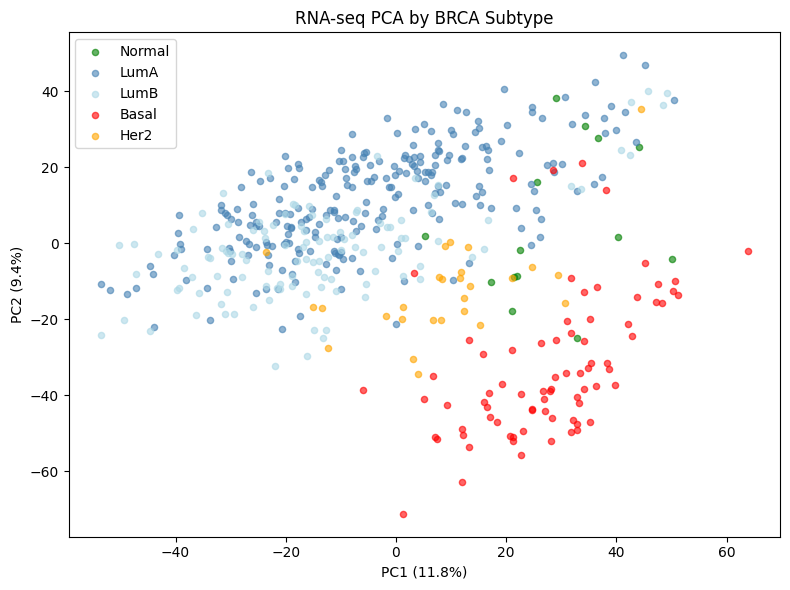

In [45]:
# Define colors for each subtype
colors = {'LumA': 'steelblue', 'LumB': 'lightblue', 
          'Basal': 'red', 'Her2': 'orange', 'Normal': 'green'}

plt.figure(figsize=(8, 6))
for subtype in clinical_aligned['PAM50'].unique():
    mask = clinical_aligned['PAM50'] == subtype
    plt.scatter(rna_pca[mask, 0], rna_pca[mask, 1],
                label=subtype, color=colors[subtype],
                alpha=0.6, s=20)

plt.xlabel(f"PC1 ({pca_rna.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca_rna.explained_variance_ratio_[1]:.1%})")
plt.title("RNA-seq PCA by BRCA Subtype")
plt.legend()
plt.tight_layout()
plt.savefig('/scratch/arumuganainar.d/projects/Multiomics/data/processed/rnaseq_pca.png', dpi=100)
plt.show()

### 5.2 PCA on Methylation

Methylation PCA shape: (486, 50)
Variance explained: 62.95%


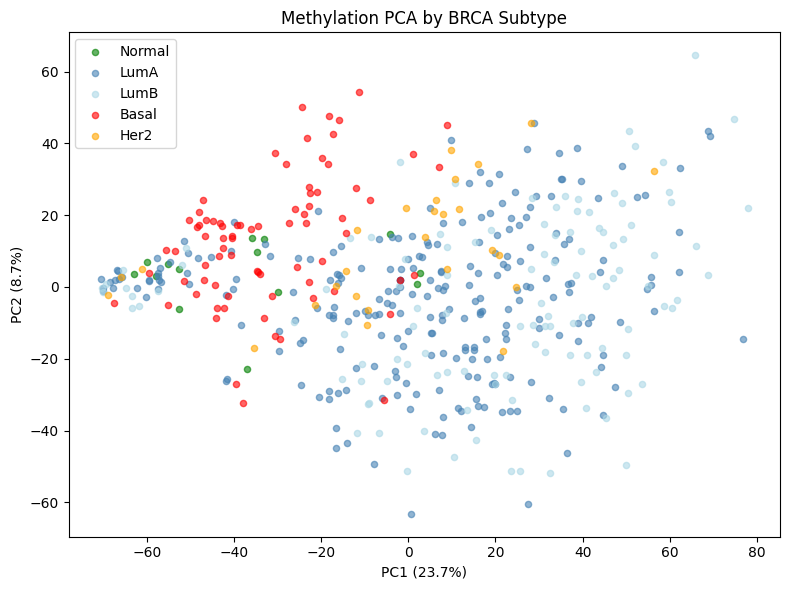

In [46]:
X_meth = meth_aligned.T.values

pca_meth = PCA(n_components=50)
meth_pca = pca_meth.fit_transform(X_meth)

print(f"Methylation PCA shape: {meth_pca.shape}")
print(f"Variance explained: {pca_meth.explained_variance_ratio_.sum():.2%}")

# Plot
plt.figure(figsize=(8, 6))
for subtype in clinical_aligned['PAM50'].unique():
    mask = clinical_aligned['PAM50'] == subtype
    plt.scatter(meth_pca[mask, 0], meth_pca[mask, 1],
                label=subtype, color=colors[subtype], alpha=0.6, s=20)

plt.xlabel(f"PC1 ({pca_meth.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca_meth.explained_variance_ratio_[1]:.1%})")
plt.title("Methylation PCA by BRCA Subtype")
plt.legend()
plt.tight_layout()
plt.savefig('/scratch/arumuganainar.d/projects/Multiomics/data/processed/meth_pca.png', dpi=100)
plt.show()

### 5.3 PCA on Mutation

Mutation PCA shape: (486, 10)
Variance explained: 77.64%


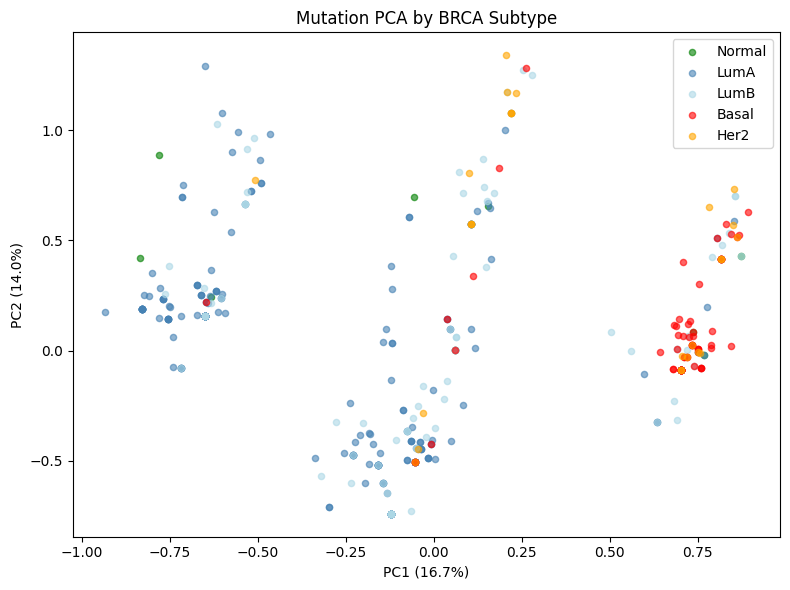

In [47]:
# Mutation matrix is already samples x genes — no transpose needed
X_mut = mut_aligned.values

pca_mut = PCA(n_components=10)
mut_pca = pca_mut.fit_transform(X_mut)

print(f"Mutation PCA shape: {mut_pca.shape}")
print(f"Variance explained: {pca_mut.explained_variance_ratio_.sum():.2%}")

# Plot
plt.figure(figsize=(8, 6))
for subtype in clinical_aligned['PAM50'].unique():
    mask = clinical_aligned['PAM50'] == subtype
    plt.scatter(mut_pca[mask, 0], mut_pca[mask, 1],
                label=subtype, color=colors[subtype], alpha=0.6, s=20)

plt.xlabel(f"PC1 ({pca_mut.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca_mut.explained_variance_ratio_[1]:.1%})")
plt.title("Mutation PCA by BRCA Subtype")
plt.legend()
plt.tight_layout()
plt.savefig('/scratch/arumuganainar.d/projects/Multiomics/data/processed/mut_pca.png', dpi=100)
plt.show()

In [48]:
# Save PCA results as dataframes
rna_pca_df = pd.DataFrame(rna_pca, index=clinical_aligned.index,
                           columns=[f'RNA_PC{i+1}' for i in range(50)])

meth_pca_df = pd.DataFrame(meth_pca, index=clinical_aligned.index,
                            columns=[f'METH_PC{i+1}' for i in range(50)])

mut_pca_df = pd.DataFrame(mut_pca, index=clinical_aligned.index,
                           columns=[f'MUT_PC{i+1}' for i in range(10)])

print(rna_pca_df.shape)
print(meth_pca_df.shape)
print(mut_pca_df.shape)

(486, 50)
(486, 50)
(486, 10)


## Section 6: Multi-Omics Integration
Combining RNA-seq, methylation, mutation PCA results and clinical features into one feature matrix for machine learning.

### 6.1 Combine All Omics into One Feature Matrix
Concatenating all PCA results and clinical features side by side — 486 patients × 114 features.

In [49]:
X = pd.concat([rna_pca_df, meth_pca_df, mut_pca_df, clinical_features], axis=1)
y = clinical_aligned['PAM50']

print(f"Final feature matrix shape: {X.shape}")
print(f"\nMissing values: {X.isnull().sum().sum()}")
print(f"\nLabel distribution:\n{y.value_counts()}")

Final feature matrix shape: (486, 114)

Missing values: 0

Label distribution:
PAM50
LumA      252
LumB      116
Basal      77
Her2       27
Normal     14
Name: count, dtype: int64


In [50]:
# Save final feature matrix
X.to_parquet("/scratch/arumuganainar.d/projects/Multiomics/data/processed/X_final.parquet")
y.to_csv("/scratch/arumuganainar.d/projects/Multiomics/data/processed/y_final.csv")
print("Saved!")

Saved!


## Section 7: Model Training & Evaluation
Training and comparing three classifiers — Logistic Regression, Random Forest, and XGBoost — using stratified cross-validation to handle class imbalance.

### 7.1 Train/Test Split

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTraining label distribution:\n{y_train.value_counts()}")
print(f"\nTest label distribution:\n{y_test.value_counts()}")

Training set: (388, 114)
Test set: (98, 114)

Training label distribution:
PAM50
LumA      201
LumB       93
Basal      61
Her2       22
Normal     11
Name: count, dtype: int64

Test label distribution:
PAM50
LumA      51
LumB      23
Basal     16
Her2       5
Normal     3
Name: count, dtype: int64


### 7.2 Logistic Regression (Baseline)

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr_scores = cross_val_score(lr, X_train, y_train, cv=cv, scoring='accuracy')

print(f"Logistic Regression CV Accuracy: {lr_scores.mean():.3f} ± {lr_scores.std():.3f}")

Logistic Regression CV Accuracy: 0.755 ± 0.046


### 7.3 Random Forest

In [53]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
rf_scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring='accuracy')

print(f"Random Forest CV Accuracy: {rf_scores.mean():.3f} ± {rf_scores.std():.3f}")

Random Forest CV Accuracy: 0.747 ± 0.018


### 7.4 XGBoost

In [54]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# XGBoost needs numeric labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

xgb = XGBClassifier(n_estimators=500, 
                     learning_rate=0.1, 
                     max_depth=6, 
                     random_state=42, 
                     n_jobs=-1,
                     eval_metric='mlogloss')

xgb_scores = cross_val_score(xgb, X_train, y_train_enc, cv=cv, scoring='accuracy')
print(f"XGBoost CV Accuracy: {xgb_scores.mean():.3f} ± {xgb_scores.std():.3f}")

XGBoost CV Accuracy: 0.773 ± 0.021


### 7.5 Final Model Evaluation on Test Set

Logistic Regression Test Accuracy: 0.755
Random Forest Test Accuracy: 0.776
XGBoost Test Accuracy: 0.816
Test Accuracy: 0.816

Classification Report:
              precision    recall  f1-score   support

       Basal       0.88      0.94      0.91        16
        Her2       0.83      1.00      0.91         5
        LumA       0.82      0.88      0.85        51
        LumB       0.72      0.57      0.63        23
      Normal       1.00      0.67      0.80         3

    accuracy                           0.82        98
   macro avg       0.85      0.81      0.82        98
weighted avg       0.81      0.82      0.81        98



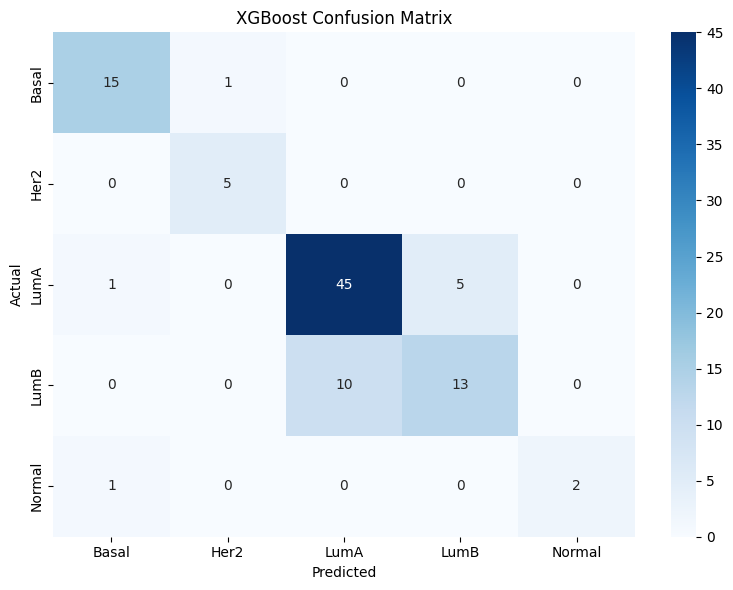

In [61]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Evaluate all three models on test set
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_test_acc = accuracy_score(y_test, lr_pred)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_test_acc = accuracy_score(y_test, rf_pred)

print(f"Logistic Regression Test Accuracy: {lr_test_acc:.3f}")
print(f"Random Forest Test Accuracy: {rf_test_acc:.3f}")
print(f"XGBoost Test Accuracy: 0.816")
# Train on full training set
xgb.fit(X_train, y_train_enc)

# Predict on test set
y_pred_enc = xgb.predict(X_test)
y_pred = le.inverse_transform(y_pred_enc)

# Accuracy
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.3f}")

# Classification report
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=le.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=le.classes_, 
            yticklabels=le.classes_,
            cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.tight_layout()
plt.savefig('/scratch/arumuganainar.d/projects/Multiomics/data/processed/confusion_matrix.png', dpi=100)
plt.show()

## Section 8: Model Interpretation
Using SHAP values to identify the most important biomarkers driving subtype predictions.

### 8.1 SHAP Feature Importance

<Figure size 640x480 with 0 Axes>

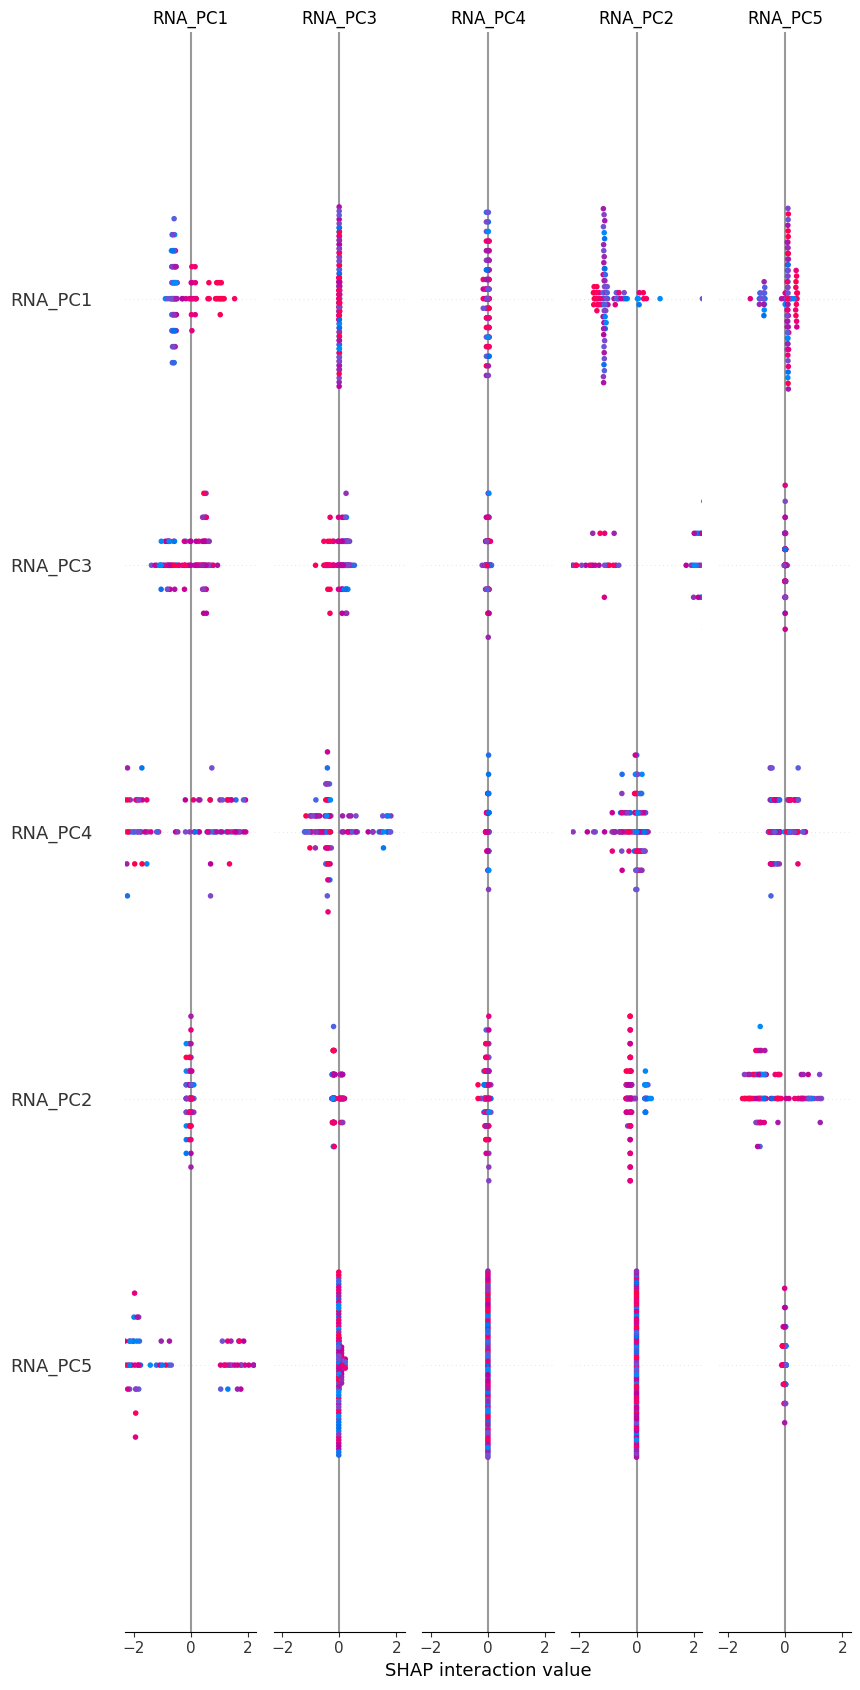

In [56]:
import shap

# Compute SHAP values
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

# Summary plot — top features across all subtypes
plt.figure()
shap.summary_plot(shap_values, X_test, 
                  class_names=le.classes_,
                  max_display=20,
                  show=False)
plt.tight_layout()
plt.savefig('/scratch/arumuganainar.d/projects/Multiomics/data/processed/shap_summary.png', dpi=100, bbox_inches='tight')
plt.show()

In [57]:
import shap
import numpy as np

# Compute SHAP values
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)
shap_array = np.array(shap_values)  # ← this line was missing

print(f"shap_array shape: {shap_array.shape}")

shap_array shape: (98, 114, 5)


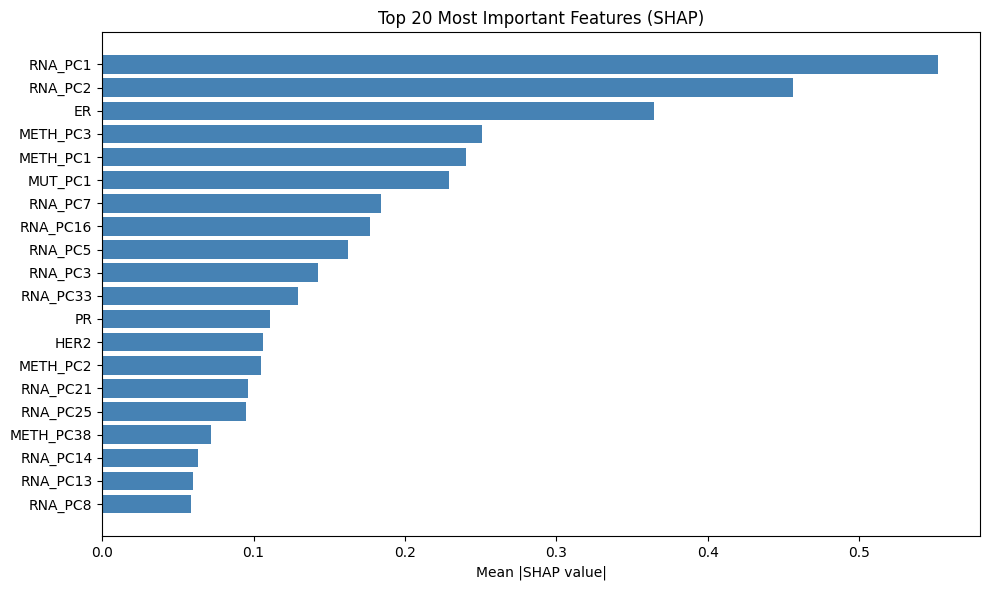


Top 10 features:
      feature  importance
0     RNA_PC1    0.552115
1     RNA_PC2    0.455991
110        ER    0.364436
52   METH_PC3    0.250717
50   METH_PC1    0.239977
100   MUT_PC1    0.228775
6     RNA_PC7    0.184324
15   RNA_PC16    0.176656
4     RNA_PC5    0.162540
2     RNA_PC3    0.142754


In [58]:
mean_shap = np.abs(shap_array).mean(axis=(0, 2))

shap_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': mean_shap
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.barh(shap_df['feature'][::-1], shap_df['importance'][::-1], color='steelblue')
plt.xlabel("Mean |SHAP value|")
plt.title("Top 20 Most Important Features (SHAP)")
plt.tight_layout()
plt.savefig('/scratch/arumuganainar.d/projects/Multiomics/data/processed/shap_importance.png', dpi=100)
plt.show()

print("\nTop 10 features:")
print(shap_df.head(10).to_string())

### 8.2 ROC Curves

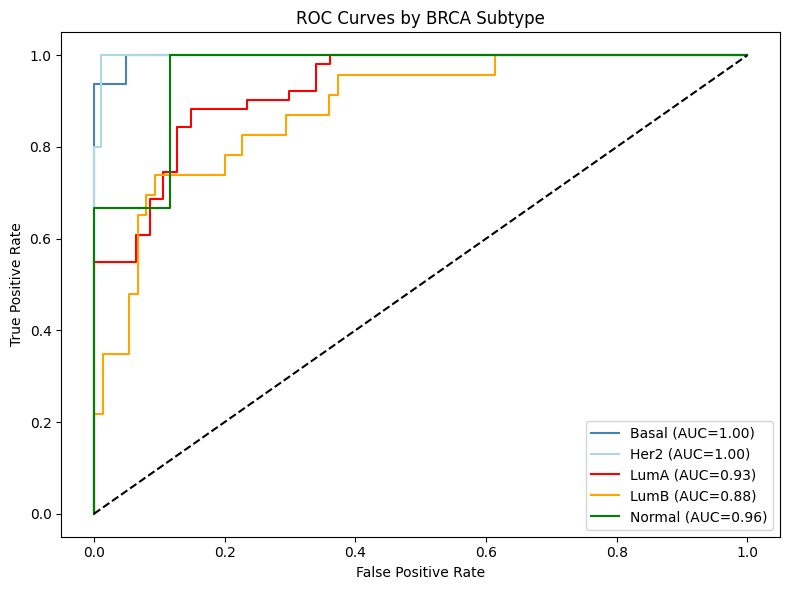

In [59]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize labels for ROC
y_test_bin = label_binarize(y_test, classes=le.classes_)
y_pred_proba = xgb.predict_proba(X_test)

plt.figure(figsize=(8, 6))
colors = ['steelblue', 'lightblue', 'red', 'orange', 'green']

for i, (subtype, color) in enumerate(zip(le.classes_, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, label=f'{subtype} (AUC={roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves by BRCA Subtype")
plt.legend()
plt.tight_layout()
plt.savefig('/scratch/arumuganainar.d/projects/Multiomics/data/processed/roc_curves.png', dpi=100)
plt.show()

In [60]:
# Run this to confirm final results are correct
print(f"Final feature matrix: {X.shape}")
print(f"Test accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"Patients: {len(y)}")

Final feature matrix: (486, 114)
Test accuracy: 0.816
Patients: 486
